# Focused run: Experiment 4 (final, 8 seeds, +Ntr=25) and Experiment 6 (real MNIST backgrounds)

Standalone -- run top to bottom on a GPU runtime. Contains only the definitions these two experiments need; nothing else retrains.

In [1]:
import warnings
import math
import torch
import torch.nn as nn
from collections import deque


def stable_svd(X, full_matrices=False):
    # cusolver's default gesvdj can fail to converge on ill-conditioned / repeated-singular-value
    # matrices (common with grid-structured data). Use the accurate gesvd driver on CUDA,
    # and fall back to CPU LAPACK if it still fails. Gradients flow through both paths.
    try:
        if X.is_cuda:
            return torch.linalg.svd(X, full_matrices=full_matrices, driver='gesvd')
        return torch.linalg.svd(X, full_matrices=full_matrices)
    except torch.linalg.LinAlgError:
        U, S, Vh = torch.linalg.svd(X.cpu(), full_matrices=full_matrices)
        return U.to(X.device), S.to(X.device), Vh.to(X.device)


class StableSVD(torch.autograd.Function):
    """
    Custom analytic-gradient SVD. The forward pass uses `stable_svd` (gesvd
    driver on CUDA, CPU LAPACK fallback) for numerical robustness; the
    backward pass implements the analytic SVD gradient by hand instead of
    relying on autograd through torch.linalg.svd.
    """

    @staticmethod
    def forward(ctx, A):
        U, S, Vh = stable_svd(A, full_matrices=False)

        ctx.save_for_backward(U, S, Vh)
        ctx.original_shape = A.shape

        return U, S, Vh

    @staticmethod
    def backward(ctx, dU, dS, dVh):
        """
        Backward pass for stable SVD.
        Computes gradient w.r.t. input A given gradients on U, S, Vh.
        """
        U, S, Vh = ctx.saved_tensors
        m, n = ctx.original_shape[-2:]

        dtype = U.dtype
        device = U.device

        H = lambda x: x.transpose(-2, -1).conj()
        T = lambda x: x.transpose(-2, -1)

        # Diagonal helpers
        def diag_embed(x):
            return torch.diag_embed(x)

        # Singular value vector to diagonal for broadcasting
        S_mat = S.unsqueeze(-2)
        S_diff = S_mat - S_mat.transpose(-2, -1)

        # F matrix for repeated singular values
        eps = 1e-20
        F = torch.where(S_diff.abs() > eps, 1.0 / S_diff, torch.zeros_like(S_diff))

        # Gradient from singular values
        dA = U @ diag_embed(dS) @ Vh

        # Contributions from U
        Ut_dU = H(U) @ dU
        skew_U = F * (Ut_dU - Ut_dU.transpose(-2, -1))
        dA += U @ skew_U @ diag_embed(S) @ Vh

        # Contributions from V
        V = H(Vh)  # n x k
        Vt_dV = H(V) @ H(dVh)  # k x k
        skew_V = F * (Vt_dV - Vt_dV.transpose(-2, -1))
        dA += U @ diag_embed(S) @ skew_V @ Vh

        # Rectangular adjustments (like JAX)
        # s_inv = 1 / S with stable zero handling
        s_zeros = (S == 0).to(dtype)
        s_inv = 1.0 / (S + s_zeros) - s_zeros  # shape: (k,)

        if m > n:
            dAV = dA @ V
            dA += (dAV - U @ (H(U) @ dAV)) * s_inv
        elif n > m:
            dAHU = H(dA) @ U
            dA += H(dAHU - V @ (Vh @ dAHU)) * s_inv.unsqueeze(1)

        return dA


class RRLayer(nn.Module):
    r"""
    Rank Reduction (RR) layer.

    During training, the layer computes a truncated SVD across the batch
    dimension and reconstructs the input using the top ``rank`` singular
    components.

    During evaluation, the layer projects the input onto a learned inference
    basis obtained from the recent training bases.

    A custom basis can always be supplied through the ``basis`` argument of
    :meth:`forward`, in which case the train/eval behavior is bypassed.

    Args:
        rank (int):
            Number of singular values to retain.

        basis_history_size (int, optional):
            Number of recent batch bases to keep when estimating the inference
            basis. Default: 20.

        svd_backend (str, optional):
            Which SVD implementation to use internally:
              - "custom": ``StableSVD.apply`` -- the hand-written analytic
                backward defined above.
              - "torch": ``stable_svd(...)`` directly -- PyTorch's native
                autograd through ``torch.linalg.svd``.
            Default: "torch".

    Shape:
        - Input: ``(N, *)``
        - Output: ``(N, *)``

    Example:
        >>> rr = RRLayer(rank=8)
        >>> rr.train()
        >>> y = rr(torch.randn(32, 768))

        >>> rr.eval()
        >>> y = rr(torch.randn(32, 768))
    """

    def __init__(
        self,
        rank: int,
        basis_history_size: int = 20,
        svd_backend: str = "torch",
    ):
        super().__init__()

        if rank <= 0:
            raise ValueError(
                f"rank must be positive, got {rank}."
            )

        if basis_history_size <= 0:
            raise ValueError(
                f"basis_history_size must be positive, got "
                f"{basis_history_size}."
            )

        if svd_backend not in ("custom", "torch"):
            raise ValueError(
                f"svd_backend must be 'custom' or 'torch', got {svd_backend!r}."
            )

        self.rank = rank
        self.basis_history_size = basis_history_size
        self.svd_backend = svd_backend

        self.register_buffer(
            "inference_basis",
            None,
            persistent=True,
        )

        self._basis_bank = deque(
            maxlen=basis_history_size,
        )

    def _svd(self, X: torch.Tensor):
        """Dispatches to the configured SVD backend."""
        if self.svd_backend == "custom":
            return StableSVD.apply(X)
        return stable_svd(X, full_matrices=False)

    def extra_repr(self) -> str:
        return (
            f"rank={self.rank}, "
            f"basis_history_size={self.basis_history_size}, "
            f"svd_backend={self.svd_backend!r}"
        )

    def train(self, mode: bool = True):
        """
        Switch between training and evaluation mode.

        When switching from training to evaluation for the first time,
        an inference basis is automatically computed from the stored
        training bases.
        """

        previous_mode = self.training

        super().train(mode)

        if (
            previous_mode
            and not mode
            and self.inference_basis is None
            and len(self._basis_bank) > 0
        ):
            self.finalize_basis()

        return self

    @torch.no_grad()
    def finalize_basis(self) -> None:
        """
        Build the inference basis from the stored training bases.
        """

        if len(self._basis_bank) == 0:
            raise RuntimeError(
                "Cannot finalize basis: no stored bases available."
            )

        device = next(self.parameters(), None)

        if device is None:
            device = self.inference_basis.device \
                if self.inference_basis is not None \
                else self._basis_bank[0].device
        else:
            device = device.device

        W = torch.cat(
            [
                basis.to(device)
                for basis in self._basis_bank
            ],
            dim=1,
        )

        U, _, _ = self._svd(W)

        r = min(self.rank, U.shape[1])

        self.inference_basis = U[:, :r]

    @torch.no_grad()
    def finalize_basis_from_data(self, x: torch.Tensor) -> None:
        """
        Build the inference basis directly from a large batch of real data,
        rather than concatenating many small per-minibatch training bases.

        This gives a basis much closer to a true full-dataset SVD -- which
        is what the downstream layers are implicitly trained to expect --
        instead of an average of noisy, small-sample bases.

        x: shape (N, *), same convention as forward()'s input.
        """
        original_shape = x.shape
        batch_size = original_shape[0]

        X = torch.movedim(x, 0, -1)
        X = X.reshape(-1, batch_size)

        U, _, _ = self._svd(X)
        r = min(self.rank, U.shape[1])
        self.inference_basis = U[:, :r]

    def _validate_inputs(
        self,
        x: torch.Tensor,
        basis: torch.Tensor | None,
    ) -> None:
        """
        Validate inputs for RRLayer.
        """

        if not isinstance(x, torch.Tensor):
            raise TypeError(
                f"x must be a torch.Tensor, got {type(x)}."
            )

        if x.ndim < 2:
            raise ValueError(
                "RRLayer expects input of shape (N, ...), "
                f"got shape {tuple(x.shape)}."
            )

        if x.shape[0] == 0:
            raise ValueError(
                "Batch size must be greater than zero."
            )

        if not torch.isfinite(x).all():
            raise ValueError(
                "Input tensor contains NaN or Inf values."
            )

        M = math.prod(x.shape[1:])
        N = x.shape[0]

        rank_max = min(M, N)

        if self.rank > rank_max:
            warnings.warn(
                f"Requested rank={self.rank}, but the maximum "
                f"achievable rank is {rank_max}. "
                f"Using rank={rank_max}.",
                stacklevel=2,
            )

        if basis is not None:

            if not isinstance(basis, torch.Tensor):
                raise TypeError(
                    f"basis must be a torch.Tensor, got {type(basis)}."
                )

            if basis.ndim != 2:
                raise ValueError(
                    "basis must have shape (M, r), "
                    f"got shape {tuple(basis.shape)}."
                )

            if basis.shape[0] != M:
                raise ValueError(
                    f"basis has {basis.shape[0]} rows but "
                    f"expected {M}."
                )

            if basis.shape[1] == 0:
                raise ValueError(
                    "basis must contain at least one column."
                )

            if basis.device != x.device:
                raise ValueError(
                    f"basis is on {basis.device} while "
                    f"x is on {x.device}."
                )

            if basis.dtype != x.dtype:
                raise ValueError(
                    f"basis dtype ({basis.dtype}) does not match "
                    f"x dtype ({x.dtype})."
                )

            if not torch.isfinite(basis).all():
                raise ValueError(
                    "basis contains NaN or Inf values."
                )

    def forward(
        self,
        x: torch.Tensor,
        basis: torch.Tensor | None = None,
        return_factors: bool = False,
    ):
        self._validate_inputs(x, basis)

        original_shape = x.shape
        batch_size = original_shape[0]

        X = torch.movedim(x, 0, -1)
        X = X.reshape(-1, batch_size)

        if basis is not None:

            basis_used = basis

            coeffs = basis_used.T @ X

            X_hat = basis_used @ coeffs

        elif self.training:

            U, S, Vh = self._svd(X)

            r = min(self.rank, S.shape[0])

            basis_used = U[:, :r]

            coeffs = (
                S[:r].unsqueeze(1)
                * Vh[:r]
            )

            X_hat = basis_used @ coeffs

            self._basis_bank.append(
                basis_used.detach().cpu()
            )

        else:

            if self.inference_basis is None:
                raise RuntimeError(
                    "RRLayer has no inference basis. "
                    "Call finalize_basis() or run training "
                    "before evaluation."
                )

            # basis bank lives on CPU, so the finalized basis may be too -- follow x
            basis_used = self.inference_basis.to(device=X.device, dtype=X.dtype)

            coeffs = basis_used.T @ X

            X_hat = basis_used @ coeffs

        output = X_hat.reshape(
            *original_shape[1:],
            batch_size,
        )

        output = torch.movedim(
            output,
            -1,
            0,
        )

        if return_factors:
            return output, basis_used, coeffs

        return output

In [2]:
import numpy as np

D = 64        # Dimension of the domain
SIGMA = 0.2   # Gaussian blob width


def gaussian_2d(x, y, x0, y0, sigma):
    return np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))


def generate_data(seed, Ntr=800, Nte=200, D=64, sigma=0.2):
    """
    Generates a fresh train/test split of Gaussian-blob images.

    Unlike drawing from the ambient numpy global RNG state (which makes the
    dataset different every run even with a fixed torch seed for the model),
    this uses a dedicated np.random.RandomState(seed), so a given `seed`
    reproduces the same dataset every time - and different seeds give
    genuinely different datasets, which is what we want when averaging
    results over multiple seeds below.
    """
    rng = np.random.RandomState(seed)

    x = np.linspace(-1, 1, D)
    y = np.linspace(-1, 1, D)
    X, Y = np.meshgrid(x, y)

    x0_tr = rng.uniform(-0.5, 0.5, Ntr)
    y0_tr = rng.uniform(-0.5, 0.5, Ntr)
    train_data = np.stack(
        [gaussian_2d(X, Y, x0_tr[i], y0_tr[i], sigma) for i in range(Ntr)], axis=-1
    )

    x0_te = rng.uniform(-0.5, 0.5, Nte)
    y0_te = rng.uniform(-0.5, 0.5, Nte)
    test_data = np.stack(
        [gaussian_2d(X, Y, x0_te[i], y0_te[i], sigma) for i in range(Nte)], axis=-1
    )

    # Normalize the data
    train_data = (train_data - np.mean(train_data)) / np.std(train_data)
    test_data = (test_data - np.mean(test_data)) / np.std(test_data)

    # Permute image tensors to (N, C, H, W)
    x_train = np.moveaxis(np.expand_dims(train_data, 0), -1, 0).astype(np.float32)
    x_test = np.moveaxis(np.expand_dims(test_data, 0), -1, 0).astype(np.float32)

    # Target coordinate tensors (N, 2)
    p_train = np.stack([x0_tr, y0_tr], axis=-1).astype(np.float32)
    p_test = np.stack([x0_te, y0_te], axis=-1).astype(np.float32)

    return x_train, p_train, x_test, p_test


# Demo call -- used by the preview plot below and by the "Prepare dataset" section.
x_train, p_train, x_test, p_test = generate_data(seed=0, Ntr=800, Nte=200, D=D, sigma=SIGMA)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("p_train shape:", p_train.shape)
print("p_test shape:", p_test.shape)

x_train shape: (800, 1, 64, 64)
x_test shape: (200, 1, 64, 64)
p_train shape: (800, 2)
p_test shape: (200, 2)


In [3]:
import torch
from torch.utils.data import Dataset

class GaussianCenterDataset(Dataset):
    """
    Wraps the generated Gaussian-blob images and their (x0, y0) centers.

    x: (N, 1, 64, 64) float32 image tensor
    p: (N, 2)         float32 center-position tensor
    """
    def __init__(self, x: np.ndarray, p: np.ndarray):
        self.x = torch.as_tensor(x, dtype=torch.float32)
        self.p = torch.as_tensor(p, dtype=torch.float32)

        assert self.x.shape[0] == self.p.shape[0], (
            f"Mismatched sample count: x has {self.x.shape[0]}, "
            f"p has {self.p.shape[0]}"
        )

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.p[idx]

In [4]:
def make_feature_extractor(depth: int = 3, norm: str | None = None,
                           rank: int = 8, svd_backend: str = "torch"):
    """
    Builds `depth` conv blocks. Channels go 1 -> 8 -> 16 -> 32.
    Pooling is removed, so spatial size stays D x D throughout.

    `norm` controls what sits between each Conv2d and its ReLU
    (i.e. the normalization comes BEFORE the activation):
      - None:  conv -> relu                    (plain OA)
      - "bn":  conv -> BatchNorm2d -> relu     (BN before activation)
      - "rr":  conv -> RRLayer -> relu         (RRLayer flattens (N, C, H, W)
               to a matrix internally and unflattens after -- the
               "flatten, RR, unflatten" step)
    """
    channel_sizes = [1, 8, 16, 32]
    if not (1 <= depth <= len(channel_sizes) - 1):
        raise ValueError(f"depth must be in [1, {len(channel_sizes) - 1}], got {depth}.")

    layers = []
    for i in range(depth):
        layers.append(nn.Conv2d(channel_sizes[i], channel_sizes[i + 1], kernel_size=3, padding=1))
        if norm == "bn":
            layers.append(nn.BatchNorm2d(channel_sizes[i + 1]))
        elif norm == "rr":
            layers.append(RRLayer(rank=rank, svd_backend=svd_backend))
        layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)


def feature_extractor_output_dim(depth: int, D: int = 64):
    """Flattened output size of make_feature_extractor(depth) for a D x D input (no pooling)."""
    channel_sizes = [1, 8, 16, 32]
    return channel_sizes[depth] * D * D

In [5]:
import torch
import torch.nn as nn


class OA(nn.Module):
    def __init__(self, depth: int = 3, D: int = 64):
        super(OA, self).__init__()
        self.features = make_feature_extractor(depth)
        flat_dim = feature_extractor_output_dim(depth, D)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [6]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Global experiment configuration ----
N_SEEDS = 32                             # 4x runs
SEEDS = list(range(2000, 2000 + N_SEEDS))

NTR_DEFAULT = 800
NTE_DEFAULT = 200
RANK = 8
EPOCHS_DEFAULT = 20
LR_DEFAULT = 1e-3
BATCH_SIZE = 32
DEPTH_DEFAULT = 3

print(f"Using device: {device}")
print(f"N_SEEDS={N_SEEDS}, SEEDS={SEEDS}")

Using device: cuda
N_SEEDS=32, SEEDS=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031]


In [7]:
# --- OA / OA_BN / OA_RR model variants + shared helpers for the focused experiments ---
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

SEEDS_FOCUS = SEEDS[:16]   # 4x runs
colors = {'OA': 'tab:blue', 'OA_BN': 'tab:orange', 'OA_RR': 'tab:green'}


class OA_BN(nn.Module):
    """BatchNorm2d inserted after every conv layer, before its ReLU."""

    def __init__(self, depth: int = 3, D: int = 64):
        super().__init__()
        self.features = make_feature_extractor(depth, norm="bn")
        flat_dim = feature_extractor_output_dim(depth, D)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


class OA_RR(nn.Module):
    """RRLayer inserted after every conv layer, before its ReLU."""

    def __init__(self, rank: int = 8, depth: int = 3, D: int = 64, svd_backend: str = "torch"):
        super().__init__()
        self.features = make_feature_extractor(depth, norm="rr", rank=rank, svd_backend=svd_backend)
        flat_dim = feature_extractor_output_dim(depth, D)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def build_models(seed, depth=DEPTH_DEFAULT, rank=RANK, D=64, svd_backend="torch"):
    """
    Builds OA / OA_BN / OA_RR, re-applying the SAME seed before each
    constructor call, so their shared Conv2d/Linear layers get identical
    initial weights -- the only difference between the three models is
    the per-layer bottleneck (none / BatchNorm2d / RRLayer).
    """
    torch.manual_seed(seed)
    m_oa = OA(depth=depth, D=D)
    torch.manual_seed(seed)
    m_bn = OA_BN(depth=depth, D=D)
    torch.manual_seed(seed)
    m_rr = OA_RR(rank=rank, depth=depth, D=D, svd_backend=svd_backend)
    return {"OA": m_oa, "OA_BN": m_bn, "OA_RR": m_rr}


def add_input_noise(x, noise_std, seed):
    """Seeded additive Gaussian pixel noise."""
    if noise_std == 0.0:
        return x
    rng = np.random.RandomState(seed * 7919 + int(noise_std * 1000))
    return (x + noise_std * rng.randn(*x.shape)).astype(np.float32)


def train_model(model, train_loader, device, epochs, lr=LR_DEFAULT):
    criterion = nn.MSELoss()
    opt = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    model.to(device)
    history = []
    for _ in range(epochs):
        model.train()
        running = 0.0
        for x_batch, p_batch in train_loader:
            x_batch, p_batch = x_batch.to(device), p_batch.to(device)
            opt.zero_grad()
            loss = criterion(model(x_batch), p_batch)
            loss.backward()
            opt.step()
            running += loss.item() * x_batch.size(0)
        history.append(running / len(train_loader.dataset))
    return history


@torch.no_grad()
def eval_model(model, test_loader, device):
    model.eval()
    criterion = nn.MSELoss()
    total, l2 = 0.0, []
    for x_batch, p_batch in test_loader:
        x_batch, p_batch = x_batch.to(device), p_batch.to(device)
        preds = model(x_batch)
        total += criterion(preds, p_batch).item() * x_batch.size(0)
        l2.append(torch.linalg.norm(preds - p_batch, dim=1))
    cat = torch.cat(l2)
    return {"test_mse": total / len(test_loader.dataset),
            "test_mean_l2": cat.mean().item(),
            "test_med_l2": cat.median().item()}

## Experiment 4: small data + heavy noise

The only untested regime where plain OA could plausibly lose: few training samples AND noisy inputs. Noise fixed at 1.0, Ntr swept down to 50. Epochs are scaled up as data shrinks so every config gets a comparable number of gradient updates (otherwise small-Ntr runs barely train and nothing can overfit). Reports the train/test gap explicitly -- that's the overfitting signal.

Ntr=25, noise=1.0 (32 seeds) ...
Ntr=50, noise=1.0 (32 seeds) ...
Ntr=100, noise=1.0 (32 seeds) ...
Ntr=200, noise=1.0 (32 seeds) ...
Ntr=400, noise=1.0 (32 seeds) ...


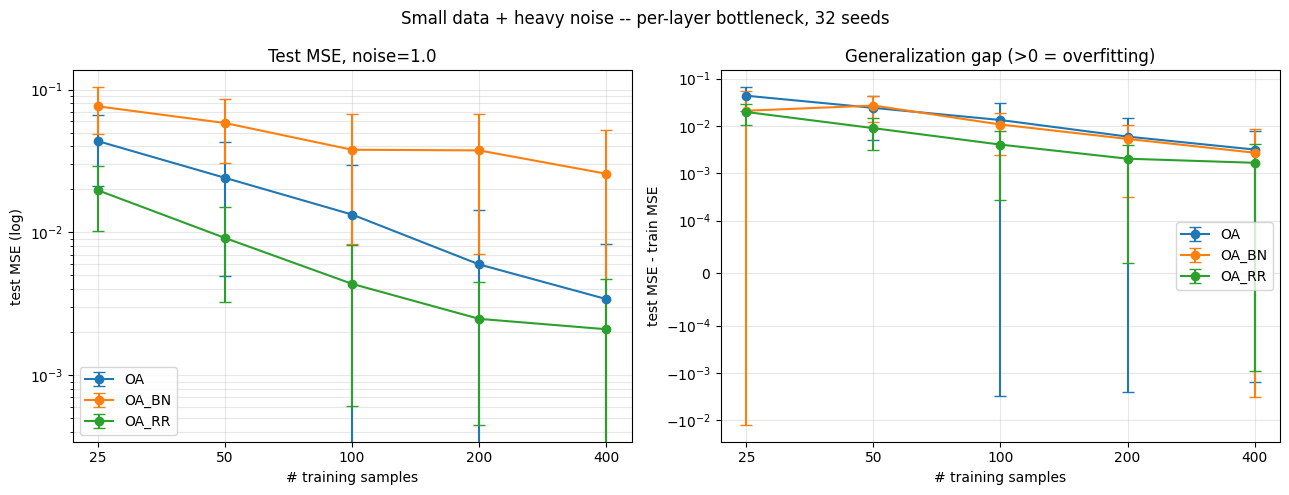

mean +- std across seeds:
  Ntr=25
       OA | train   0.0000 | test   0.0436 +-  0.0224 | gap   0.0435
    OA_BN | train   0.0554 | test   0.0763 +-  0.0276 | gap   0.0210
    OA_RR | train   0.0000 | test   0.0197 +-  0.0095 | gap   0.0197
  Ntr=50
       OA | train   0.0000 | test   0.0241 +-  0.0192 | gap   0.0241
    OA_BN | train   0.0314 | test   0.0584 +-  0.0276 | gap   0.0270
    OA_RR | train   0.0002 | test   0.0091 +-  0.0059 | gap   0.0090
  Ntr=100
       OA | train   0.0000 | test   0.0133 +-  0.0165 | gap   0.0133
    OA_BN | train   0.0272 | test   0.0379 +-  0.0296 | gap   0.0107
    OA_RR | train   0.0003 | test   0.0044 +-  0.0038 | gap   0.0040
  Ntr=200
       OA | train   0.0000 | test   0.0060 +-  0.0085 | gap   0.0060
    OA_BN | train   0.0322 | test   0.0375 +-  0.0304 | gap   0.0053
    OA_RR | train   0.0005 | test   0.0025 +-  0.0020 | gap   0.0020
  Ntr=400
       OA | train   0.0003 | test   0.0034 +-  0.0049 | gap   0.0032
    OA_BN | train   0.0230 | 

In [8]:
NTR_SMALL = [25, 50, 100, 200, 400]
SEEDS_EXP4 = SEEDS   # full 8 seeds -- this is the headline result, worth the runtime
NOISE_SMALL = 1.0


def run_seed_small(seed, ntr, noise_std=NOISE_SMALL, rank=RANK):
    """One seed at a given Ntr: noisy data -> OA/OA_BN/OA_RR (shared init) -> train -> eval.
    Epochs are scaled to keep total gradient-update budget comparable across Ntr."""
    x_tr, p_tr, x_te, p_te = generate_data(seed, Ntr=ntr, Nte=NTE_DEFAULT, D=D, sigma=SIGMA)
    x_tr = add_input_noise(x_tr, noise_std, seed)
    x_te = add_input_noise(x_te, noise_std, seed + 999)

    train_loader = DataLoader(GaussianCenterDataset(x_tr, p_tr),
                              batch_size=min(BATCH_SIZE, ntr), shuffle=True, drop_last=True)
    test_loader = DataLoader(GaussianCenterDataset(x_te, p_te),
                             batch_size=BATCH_SIZE, shuffle=False)

    epochs = EPOCHS_DEFAULT * max(1, NTR_DEFAULT // ntr)   # same update budget as Ntr=800

    models = build_models(seed, rank=rank)
    results = {}
    for name, m in models.items():
        torch.manual_seed(seed)
        hist = train_model(m, train_loader, device, epochs)
        r = eval_model(m, test_loader, device)
        r["train_mse_final"] = hist[-1]
        r["gap"] = r["test_mse"] - hist[-1]
        results[name] = r
    return results


small_aggs = []
for ntr in NTR_SMALL:
    print(f"Ntr={ntr}, noise={NOISE_SMALL} ({len(SEEDS_EXP4)} seeds) ...")
    per = [run_seed_small(s, ntr) for s in SEEDS_EXP4]
    small_aggs.append({
        name: {m: np.array([r[name][m] for r in per]) for m in per[0][name]}
        for name in per[0]
    })

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in ["OA", "OA_BN", "OA_RR"]:
    means = [agg[name]["test_mse"].mean() for agg in small_aggs]
    stds = [agg[name]["test_mse"].std() for agg in small_aggs]
    axes[0].errorbar(NTR_SMALL, means, yerr=stds, marker="o", capsize=4,
                     label=name, color=colors[name])
    gmeans = [agg[name]["gap"].mean() for agg in small_aggs]
    gstds = [agg[name]["gap"].std() for agg in small_aggs]
    axes[1].errorbar(NTR_SMALL, gmeans, yerr=gstds, marker="o", capsize=4,
                     label=name, color=colors[name])

axes[0].set_yscale("log")
axes[0].set_xlabel("# training samples")
axes[0].set_ylabel("test MSE (log)")
axes[0].set_title(f"Test MSE, noise={NOISE_SMALL}")
axes[1].set_yscale("symlog", linthresh=1e-4)
axes[1].set_xlabel("# training samples")
axes[1].set_ylabel("test MSE - train MSE")
axes[1].set_title("Generalization gap (>0 = overfitting)")
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xticks(NTR_SMALL)
    ax.set_xticklabels([str(n) for n in NTR_SMALL])
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
plt.suptitle(f"Small data + heavy noise -- per-layer bottleneck, {len(SEEDS_EXP4)} seeds")
plt.tight_layout()
plt.show()

print("mean +- std across seeds:")
for ntr, agg in zip(NTR_SMALL, small_aggs):
    print(f"  Ntr={ntr}")
    for name in ["OA", "OA_BN", "OA_RR"]:
        m = agg[name]
        print(f"    {name:>5} | train {m['train_mse_final'].mean():8.4f} "
              f"| test {m['test_mse'].mean():8.4f} +- {m['test_mse'].std():7.4f} "
              f"| gap {m['gap'].mean():8.4f}")

## Experiment 6: real backgrounds (source injection)

External-validity check using the standard astronomy methodology: inject a synthetic source with *known* position into **real** image backgrounds -- here MNIST digits (real data, structured, non-Gaussian, not low-rank by construction). Ground truth stays exact; the clutter statistics become real. Train and test use disjoint digit pools, so generalization requires ignoring backgrounds never seen in training.

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.88MB/s]


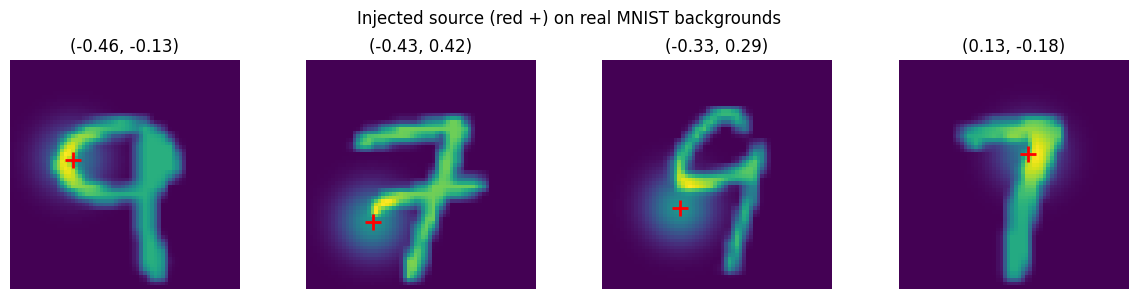

MNIST-background source injection: Ntr=200 (16 seeds) ...


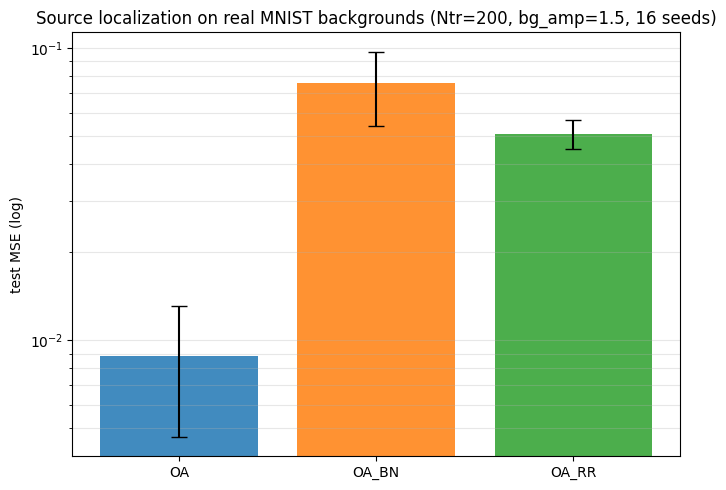

test MSE, mean +- std:
     OA |   0.0089 +-  0.0042
  OA_BN |   0.0755 +-  0.0215
  OA_RR |   0.0509 +-  0.0057


In [9]:
NTR_MNIST = 200
BG_AMP = 1.5   # background amplitude relative to the unit-height blob

from torchvision import datasets
import torch.nn.functional as F

_mnist_raw = datasets.MNIST(root="./mnist_data", train=True, download=True).data
_MNIST_IMGS = F.interpolate(_mnist_raw[:20000].unsqueeze(1).float() / 255.0,
                            size=(D, D), mode="bilinear", align_corners=False).squeeze(1).numpy()
_POOL_TR, _POOL_TE = _MNIST_IMGS[:10000], _MNIST_IMGS[10000:]   # disjoint background pools


def generate_data_mnist(seed, Ntr, Nte, D=64, sigma=0.2, bg_amp=BG_AMP):
    """Gaussian blob at a known center + real MNIST background clutter."""
    rng = np.random.RandomState(seed)
    xs = np.linspace(-1, 1, D)
    X, Y = np.meshgrid(xs, xs)

    def make_split(n, pool):
        idx = rng.choice(len(pool), size=n, replace=False)
        x0 = rng.uniform(-0.5, 0.5, n)
        y0 = rng.uniform(-0.5, 0.5, n)
        imgs = np.stack([gaussian_2d(X, Y, x0[i], y0[i], sigma) + bg_amp * pool[idx[i]]
                         for i in range(n)])
        imgs = (imgs - imgs.mean()) / imgs.std()
        return imgs[:, None].astype(np.float32), np.stack([x0, y0], -1).astype(np.float32)

    x_tr, p_tr = make_split(Ntr, _POOL_TR)
    x_te, p_te = make_split(Nte, _POOL_TE)
    return x_tr, p_tr, x_te, p_te


def run_seed_mnist(seed, ntr=NTR_MNIST, rank=RANK):
    x_tr, p_tr, x_te, p_te = generate_data_mnist(seed, Ntr=ntr, Nte=NTE_DEFAULT, D=D, sigma=SIGMA)
    train_loader = DataLoader(GaussianCenterDataset(x_tr, p_tr),
                              batch_size=min(BATCH_SIZE, ntr), shuffle=True, drop_last=True)
    test_loader = DataLoader(GaussianCenterDataset(x_te, p_te),
                             batch_size=BATCH_SIZE, shuffle=False)
    epochs = EPOCHS_DEFAULT * max(1, NTR_DEFAULT // ntr)
    models = build_models(seed, rank=rank)
    results = {}
    for name, m in models.items():
        torch.manual_seed(seed)
        train_model(m, train_loader, device, epochs)
        results[name] = eval_model(m, test_loader, device)
    return results


# preview: what the injected images look like
_xp, _pp, _, _ = generate_data_mnist(0, Ntr=4, Nte=4)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(_xp[i, 0], cmap="viridis")
    ax.plot((_pp[i, 0] + 1) / 2 * (D - 1), (_pp[i, 1] + 1) / 2 * (D - 1),
            "r+", markersize=12, markeredgewidth=2)
    ax.set_title(f"({_pp[i, 0]:.2f}, {_pp[i, 1]:.2f})")
    ax.axis("off")
plt.suptitle("Injected source (red +) on real MNIST backgrounds")
plt.tight_layout()
plt.show()

mnist_res = {}
print(f"MNIST-background source injection: Ntr={NTR_MNIST} ({len(SEEDS_FOCUS)} seeds) ...")
per = [run_seed_mnist(s) for s in SEEDS_FOCUS]
mnist_res = {name: np.array([r[name]["test_mse"] for r in per]) for name in per[0]}

fig, ax = plt.subplots(figsize=(7, 5))
names = ["OA", "OA_BN", "OA_RR"]
ax.bar(names, [mnist_res[n].mean() for n in names],
       yerr=[mnist_res[n].std() for n in names], capsize=6,
       color=[colors[n] for n in names], alpha=0.85)
ax.set_yscale("log")
ax.set_ylabel("test MSE (log)")
ax.set_title(f"Source localization on real MNIST backgrounds "
             f"(Ntr={NTR_MNIST}, bg_amp={BG_AMP}, {len(SEEDS_FOCUS)} seeds)")
ax.grid(True, axis="y", which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print("test MSE, mean +- std:")
for n in names:
    print(f"  {n:>5} | {mnist_res[n].mean():8.4f} +- {mnist_res[n].std():7.4f}")

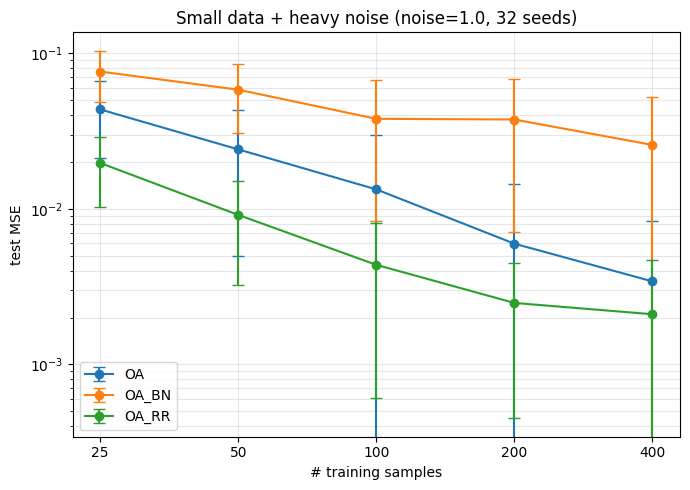

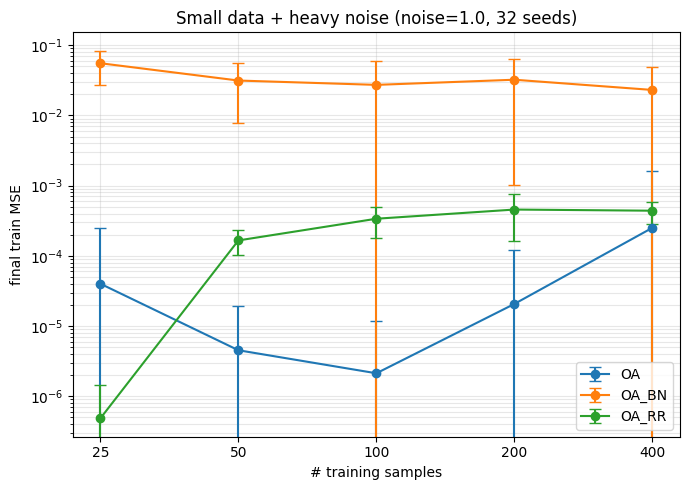

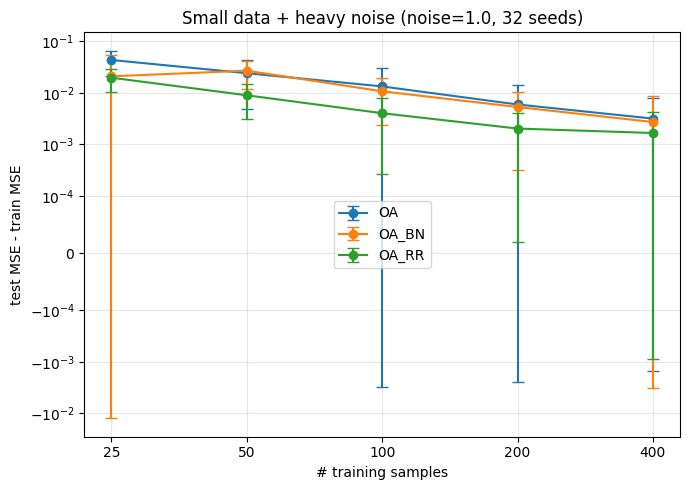

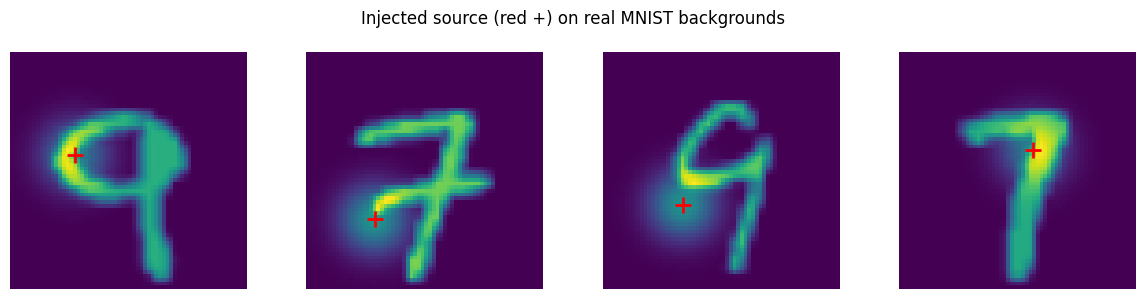

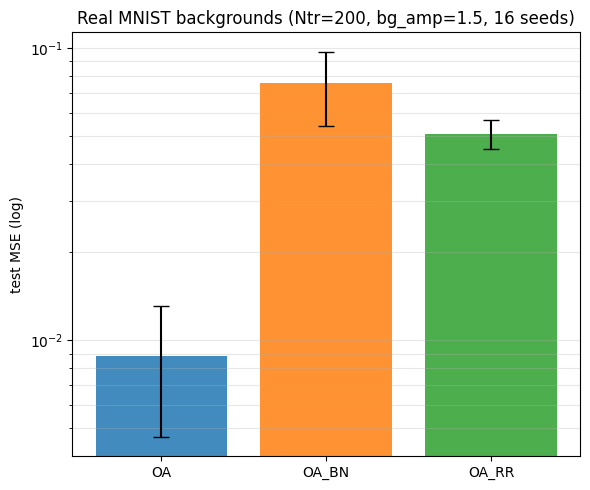

saved: ['exp4_gap.png', 'exp4_test_mse.png', 'exp4_train_mse.png', 'exp6_preview.png', 'exp6_test_mse.png'] -> poster_figs.zip


In [10]:
# === Separate poster-ready figures, one plot per file ===
import os, shutil
import matplotlib.pyplot as plt

os.makedirs("poster_figs", exist_ok=True)

def save(fig, name):
    fig.savefig(f"poster_figs/{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

MODELS = ["OA", "OA_BN", "OA_RR"]

# ---- Experiment 4: one figure per metric ----
for metric, ylabel, fname, yscale in [
    ("test_mse", "test MSE", "exp4_test_mse", "log"),
    ("train_mse_final", "final train MSE", "exp4_train_mse", "log"),
    ("gap", "test MSE - train MSE", "exp4_gap", "symlog"),
]:
    fig, ax = plt.subplots(figsize=(7, 5))
    for name in MODELS:
        means = [agg[name][metric].mean() for agg in small_aggs]
        stds = [agg[name][metric].std() for agg in small_aggs]
        ax.errorbar(NTR_SMALL, means, yerr=stds, marker="o", capsize=4,
                    label=name, color=colors[name])
    if yscale == "symlog":
        ax.set_yscale("symlog", linthresh=1e-4)
    else:
        ax.set_yscale("log")
    ax.set_xscale("log", base=2)
    ax.set_xticks(NTR_SMALL)
    ax.set_xticklabels([str(n) for n in NTR_SMALL])
    ax.set_xlabel("# training samples")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Small data + heavy noise (noise={NOISE_SMALL}, {len(SEEDS_EXP4)} seeds)")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    save(fig, fname)

# ---- Experiment 6: preview figure ----
_xp, _pp, _, _ = generate_data_mnist(0, Ntr=4, Nte=4)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(_xp[i, 0], cmap="viridis")
    ax.plot((_pp[i, 0] + 1) / 2 * (D - 1), (_pp[i, 1] + 1) / 2 * (D - 1),
            "r+", markersize=12, markeredgewidth=2)
    ax.axis("off")
fig.suptitle("Injected source (red +) on real MNIST backgrounds")
plt.tight_layout()
save(fig, "exp6_preview")

# ---- Experiment 6: results bar chart ----
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(MODELS, [mnist_res[n].mean() for n in MODELS],
       yerr=[mnist_res[n].std() for n in MODELS], capsize=6,
       color=[colors[n] for n in MODELS], alpha=0.85)
ax.set_yscale("log")
ax.set_ylabel("test MSE (log)")
ax.set_title(f"Real MNIST backgrounds (Ntr={NTR_MNIST}, "
             f"bg_amp={BG_AMP}, {len(SEEDS_FOCUS)} seeds)")
ax.grid(True, axis="y", which="both", alpha=0.3)
plt.tight_layout()
save(fig, "exp6_test_mse")

shutil.make_archive("poster_figs", "zip", "poster_figs")
print("saved:", sorted(os.listdir("poster_figs")), "-> poster_figs.zip")